# LA Crime Data (2020–2025): Exploratory Data Analysis

**Dataset:** `Crime_Data_from_2020_to_Present.csv` — Los Angeles Police Department crime incident records  
**Records:** 10,05,198 rows | **Columns:** 28  
**Time span:** 2020 – 2025  
**Source Of Dataset:** Kaggle.com

## Objectives
1. Clean and prepare the raw crime data for analysis
2. Understand the distribution of crime types, locations, and outcomes
3. Explore temporal patterns (yearly, monthly, hourly, day-of-week trends)
4. Explore geographic patterns (which areas/locations see the most crime)
5. Explore victim demographics (age, sex, descent) and their relationship to crime type
6. Summarize key insights

## Table of Contents

- [Setup & Data Loading](#1.-Setup-&-Data-Loading)
- [Initial Data Overview](#2.-Initial-Data-Overview)
- [Data Cleaning](#3.-Data-Cleaning)
- [Univariate Analysis](#4.-Univariate-Analysis)
- [Time Series Analysis](#5.-Time-Series-Analysis)
- [Geographic Analysis](#6.-Geographic-Analysis)
- [Victim Demographic](#7.-Victim-Demographic)
- [Crime Type & Weapon Analysis](#8.-Crime-Type-&-Weapon-Analysis)
- [Summary](#9.-Summary)
- [Dashboard](#10.-Dashboard)

# 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#seaborn-library 
#seaborn.set_style()-Method/Attribute : Sets the default style/theme for Seaborn plots.
sns.set_style('whitegrid')     #Apply white background with grid lines (Ex:Histogram,bar,line ..easy to understand)

#matplotlib.pyplot - library
#matplotlib.rcParams['figure.figsize'] - Method : Sets the default width and height of figures in inches.
plt.rcParams['figure.figsize'] = (10, 6)  #Set default plot size.

# matplotlib.pyplot - library
# matplotlib.rcParams['font.size'] - Method :Sets the default font size for titles, labels...
plt.rcParams['font.size'] = 10  #Set default font size

# pandas - library
# pandas.set_option() - Method : Changes pandas display settings to show all columns.
#None means no limit on the number of columns displayed
pd.set_option('display.max_columns', None)  #Show all columns

# pandas - library
# pandas.read_csv() - Method : Reads a CSV file and loads it into a DataFrame.
crime = pd.read_csv(r"C:\Users\abc\OneDrive\Documents\ShrushtiPython\Crime_Data_from_2020_to_Present.csv")


# pandas.DataFrame - library
# DataFrame.shape - Method :Returns the dimensions of the DataFrame as (rows, columns).
print(f"Dataset shape: {crime.shape[0]:,} rows x {crime.shape[1]} columns") 
# using f-string : Formats numbers with commas as thousands separators.
# 0- Returns the number of rows in the DataFrame.
# 1-Returns the number of columns in the DataFrame.

Dataset shape: 1,005,198 rows x 28 columns


# 2. Initial Data Overview   


Before cleaning anything, let's understand what we're working with —    
column types, sample rows, and where the gaps are.    

In [3]:
crime.head() #returns the first 5 rows of the Dataset

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,3/1/2020 0:00,3/1/2020 0:00,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,NaN,0,M,O,101.0,STREET,NaN,NaN,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,2/9/2020 0:00,2/8/2020 0:00,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,1822 1402 0344,47,M,O,128.0,BUS STOP/LAYOVER (ALSO QUERY 124),NaN,NaN,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 0:00,11/4/2020 0:00,1700,3,Southwest,356,1,480,BIKE - STOLEN,0344 1251,19,X,X,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",NaN,NaN,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,5/10/2023 0:00,3/10/2020 0:00,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),0325 1501,19,M,O,405.0,CLOTHING STORE,NaN,NaN,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,200412582,9/9/2020 0:00,9/9/2020 0:00,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,NaN,0,NaN,NaN,101.0,STREET,NaN,NaN,IC,Invest Cont,510.0,NaN,NaN,NaN,200 E AVENUE 28,NaN,34.0820,-118.2130


In [4]:
crime.info()  #displays a summary of the DataFrame structure.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005198 entries, 0 to 1005197
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   DR_NO           1005198 non-null  int64  
 1   Date Rptd       1005198 non-null  object 
 2   DATE OCC        1005198 non-null  object 
 3   TIME OCC        1005198 non-null  int64  
 4   AREA            1005198 non-null  int64  
 5   AREA NAME       1005198 non-null  object 
 6   Rpt Dist No     1005198 non-null  int64  
 7   Part 1-2        1005198 non-null  int64  
 8   Crm Cd          1005198 non-null  int64  
 9   Crm Cd Desc     1005198 non-null  object 
 10  Mocodes         853438 non-null   object 
 11  Vict Age        1005198 non-null  int64  
 12  Vict Sex        860416 non-null   object 
 13  Vict Descent    860404 non-null   object 
 14  Premis Cd       1005182 non-null  float64
 15  Premis Desc     1004610 non-null  object 
 16  Weapon Used Cd  327280 non-null   fl

### *1. Dataset Size*: 
                   Rows (Records): 1,005,198    
                   Columns (Features): 28    
                   Each row represents one crime incident. 

### *2. Number of non-null values in each column*:
                    Value present in each column.
### *3. Data Types*:    
                   dtypes: float64(8), int64(7), object(13)      

| Data Type | Count | Meaning             |
| --------- | ----- | ------------------- |
| object    | 13    | Text/String columns |
| int64     | 7     | Integer columns     |
| float64   | 8     | Decimal columns     |   

### *4. Memory Usage*:   
                  The dataset occupies approximately 214.7 MB in memory.       




In [5]:
#Check Misssing Values per column
missing = crime.isnull().sum()
#To see the percentage of missing values:
missing_per = (missing/len(crime)*100).round(2)
#create a DataFrame
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_per})
# Showing only the columns that contain missing values and order them -
# from the highest missing percentage to the lowest.
missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing %', ascending=False)


,Missing Count,Missing %
Crm Cd 4,1005134,99.99
Crm Cd 3,1002884,99.77
Crm Cd 2,936039,93.12
Cross Street,850955,84.66
Weapon Used Cd,677918,67.44
Weapon Desc,677918,67.44
Mocodes,151760,15.10
Vict Sex,144782,14.40
Vict Descent,144794,14.40
Premis Desc,588,0.06


**Observations on missing data:**
- `Crm Cd 2/3/4` are mostly empty — this is expected, most incidents only have one crime code (`Crm Cd 1`); these columns hold *additional* codes when multiple crimes occurred in one incident.
- `Weapon Used Cd`/`Weapon Desc` are missing for ~68% of records — most crimes (e.g. theft, burglary) simply don't involve a weapon, so this is a legitimate "not applicable" rather than a data error.
- `Vict Sex`/`Vict Descent` missing for ~14% — likely crimes with no identified victim (e.g. vandalism) or unrecorded data.
- `Cross Street` missing for ~85% — only filled when the location is described as an intersection.
- `Mocodes` (modus operandi codes) missing for ~15% of records.

We'll handle each of these deliberately in the cleaning step rather than dropping rows.

In [6]:
# Generate summary statistics for every column in the dataset.
crime.describe(include='all')

# display each column as a row for easier reading.
# T stands for transpose It swaps rows and columns.
# crime.describe(include='all').T 

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
count,1.005198e+06,1005198,1005198,1.005198e+06,1.005198e+06,1005198,1.005198e+06,1.005198e+06,1.005198e+06,1005198,853438,1.005198e+06,860416,860404,1.005182e+06,1004610,327280.000000,327280,1005197,1005198,1.005187e+06,69159.000000,2314.000000,64.00000,1005198,154243,1.005198e+06,1.005198e+06
unique,NaN,1906,1901,NaN,NaN,21,NaN,NaN,NaN,140,310956,NaN,5,20,NaN,306,NaN,79,6,6,NaN,NaN,NaN,NaN,66567,10414,NaN,NaN
top,NaN,2/2/2023 0:00,1/1/2020 0:00,NaN,NaN,Central,NaN,NaN,NaN,VEHICLE - STOLEN,344,NaN,M,H,NaN,STREET,NaN,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,NaN,NaN,NaN,NaN,800 N ALAMEDA ST,BROADWAY,NaN,NaN
freq,NaN,929,1164,NaN,NaN,69674,NaN,NaN,NaN,115247,42200,NaN,403916,296437,NaN,261389,NaN,174777,803946,803946,NaN,NaN,NaN,NaN,2598,2487,NaN,NaN
mean,2.202277e+08,NaN,NaN,1.339911e+03,1.069098e+01,NaN,1.115556e+03,1.400283e+00,5.001458e+02,NaN,NaN,2.891253e+01,NaN,NaN,3.056189e+02,NaN,363.953651,NaN,NaN,NaN,4.999063e+02,958.105221,984.015990,991.21875,NaN,NaN,3.399820e+01,-1.180909e+02
std,1.320282e+07,NaN,NaN,6.510531e+02,6.110385e+00,NaN,6.111733e+02,4.899559e-01,2.052635e+02,NaN,NaN,2.199382e+01,NaN,NaN,2.193160e+02,NaN,123.736081,NaN,NaN,NaN,2.050640e+02,110.354136,52.350982,27.06985,NaN,NaN,1.610549e+00,5.581812e+00
min,8.170000e+02,NaN,NaN,1.000000e+00,1.000000e+00,NaN,1.010000e+02,1.000000e+00,1.100000e+02,NaN,NaN,-4.000000e+00,NaN,NaN,1.010000e+02,NaN,101.000000,NaN,NaN,NaN,1.100000e+02,210.000000,310.000000,821.00000,NaN,NaN,0.000000e+00,-1.186676e+02
25%,2.106169e+08,NaN,NaN,9.000000e+02,5.000000e+00,NaN,5.870000e+02,1.000000e+00,3.310000e+02,NaN,NaN,0.000000e+00,NaN,NaN,1.010000e+02,NaN,311.000000,NaN,NaN,NaN,3.310000e+02,998.000000,998.000000,998.00000,NaN,NaN,3.401470e+01,-1.184305e+02
50%,2.209160e+08,NaN,NaN,1.420000e+03,1.100000e+01,NaN,1.139000e+03,1.000000e+00,4.420000e+02,NaN,NaN,3.000000e+01,NaN,NaN,2.030000e+02,NaN,400.000000,NaN,NaN,NaN,4.420000e+02,998.000000,998.000000,998.00000,NaN,NaN,3.405890e+01,-1.183225e+02
75%,2.311105e+08,NaN,NaN,1.900000e+03,1.600000e+01,NaN,1.613000e+03,2.000000e+00,6.260000e+02,NaN,NaN,4.400000e+01,NaN,NaN,5.010000e+02,NaN,400.000000,NaN,NaN,NaN,6.260000e+02,998.000000,998.000000,998.00000,NaN,NaN,3.416490e+01,-1.182739e+02


# 3. Data Cleaning


We'll clean step by step, checking the effect of each step.   
Nothing gets silently dropped — every transformation is explained.  

### 3.1 Check for duplicates


In [7]:
# Check how many duplicate case numbers (DR_NO) exist in the dataset
dupl_dr_no = crime['DR_NO'].duplicated().sum()

# Check how many completely identical rows exist in the dataset
dupl_rows = crime.duplicated().sum()

# Display the number of duplicate case numbers
print(f"Duplicate DR_NO (case numbers): {dupl_dr_no}")

# Display the number of fully duplicate rows
print(f"Duplicate rows: {dupl_rows}")

Duplicate DR_NO (case numbers): 0
Duplicate rows: 0


### 3.2 Parse date and time fields

Converting `Date Rptd` and `DATE OCC` to proper datetimes, and   
combining `DATE OCC` + `TIME OCC` into a single timestamp.   
We also derive Year, Month, Day, Hour, and Weekday for time series analysis later.  

In [8]:
# Convert the 'Date Rptd' column from string/object format to datetime format.
# Invalid dates will be converted to NaT (Not a Time) instead of causing an error.
crime['Date Rptd'] = pd.to_datetime(crime['Date Rptd'], errors='coerce')

# Convert the crime occurrence date column to datetime format.
# Invalid values become NaT.
crime['DATE OCC'] = pd.to_datetime(crime['DATE OCC'], errors='coerce')

# TIME OCC is stored as HHMM integer format.
# Example:
# 2130 -> 21 hours and 30 minutes
# 945  -> 9 hours and 45 minutes
#
# Integer division by 100 extracts only the hour portion:
# 2130 // 100 = 21
# 945  // 100 = 9
#
# clip(0, 23) ensures hours remain within the valid range 0-23.
crime['Hour OCC'] = (crime['TIME OCC'] // 100).clip(0, 23)

# Create a complete datetime by adding the occurrence hour
# as a time offset to the occurrence date.
#
# Example:
# DATE OCC   = 2024-05-10
# Hour OCC   = 21
#
# Result:
# Datetime OCC = 2024-05-10 21:00:00
crime['Datetime OCC'] = crime['DATE OCC'] + pd.to_timedelta(crime['Hour OCC'], unit='h')

# Extract the year from the occurrence date.
# Example:
# 2024-05-10 -> 2024
crime['Year OCC'] = crime['DATE OCC'].dt.year

# Extract the month number from the occurrence date.
# Example:
# 2024-05-10 -> 5
crime['Month OCC'] = crime['DATE OCC'].dt.month

# Extract the weekday name from the occurrence date.
# Example:
# 2024-05-10 -> Friday
crime['Weekday OCC'] = crime['DATE OCC'].dt.day_name()

# Display the first five rows of the newly created date/time features.
print(
    crime[
        ['DATE OCC',
         'TIME OCC',
         'Hour OCC',
         'Datetime OCC',
         'Year OCC',
         'Weekday OCC']
    ].head()
)

    DATE OCC  TIME OCC  Hour OCC        Datetime OCC  Year OCC Weekday OCC
0 2020-03-01      2130        21 2020-03-01 21:00:00      2020      Sunday
1 2020-02-08      1800        18 2020-02-08 18:00:00      2020    Saturday
2 2020-11-04      1700        17 2020-11-04 17:00:00      2020   Wednesday
3 2020-03-10      2037        20 2020-03-10 20:00:00      2020     Tuesday
4 2020-09-09       630         6 2020-09-09 06:00:00      2020   Wednesday


In [9]:
# Check the resulting year range
print(crime['Year OCC'].value_counts().sort_index())
#By default, value_counts() sorts by frequency (highest count first).
# Sorts the results by the year value (index) instead of by frequency.

Year OCC
2020    199847
2021    209875
2022    235258
2023    232350
2024    127574
2025       294
Name: count, dtype: int64


Inferences : Count how many crimes occurred in each year and display the years in   
chronological order to verify that the extracted years look correct.  

### 3.3 Clean victim demographics

- `Vict Sex`: standardize codes. `X` = unknown, `H`/`-` are data-entry artifacts (only ~115 rows combined) — we'll fold these into 'Unknown' along with nulls.
- `Vict Age`: 0 or negative ages appear for ~27% of records — these correspond to crimes with no individual victim (e.g. burglary of a business) rather than bad data. We'll keep them but flag them as `Vict Age Valid = False` rather than dropping, so downstream age analysis can filter cleanly.
- `Vict Descent`: LAPD uses single-letter codes (W=White, B=Black, H=Hispanic, etc.) — we'll map these to readable labels for plotting.

In [10]:
# Replace inconsistent gender codes ('H' and '-') with 'X' representing Unknown
crime['Vict Sex'] = crime['Vict Sex'].replace({'H': 'X', '-': 'X'})

# Replace missing gender values (NaN) with 'X' (Unknown)
crime['Vict Sex'] = crime['Vict Sex'].fillna('X')

# Convert gender codes into readable labels (M → Male, F → Female, X → Unknown)
# Any unmapped values are also labeled as 'Unknown'
crime['Vict Sex Label'] = crime['Vict Sex'].map({
    'M': 'Male',
    'F': 'Female',
    'X': 'Unknown'
}).fillna('Unknown')

# Create a Boolean flag indicating whether the victim age is valid
# LAPD(Los Angel Police Department) uses 0 or negative values for unknown or non-applicable ages
crime['Vict Age Valid'] = crime['Vict Age'] > 0

# Create a dictionary that maps victim descent codes
# (stored in the dataset as single letters) to readable ethnicity names.
descent_map = {
    'A': 'Other Asian',
    'B': 'Black',
    'C': 'Chinese',
    'D': 'Cambodian',
    'F': 'Filipino',
    'G': 'Guamanian',
    'H': 'Hispanic/Latin',
    'I': 'American Indian',
    'J': 'Japanese',
    'K': 'Korean',
    'L': 'Laotian',
    'O': 'Other',
    'P': 'Pacific Islander',
    'S': 'Samoan',
    'U': 'Hawaiian',
    'V': 'Vietnamese',
    'W': 'White',
    'X': 'Unknown',
    'Z': 'Asian Indian'
}

# Replace descent codes in the 'Vict Descent' column
# with their corresponding readable labels using the dictionary above.
# Any missing or unmapped values are assigned 'Unknown'.
crime['Vict Descent Label'] = crime['Vict Descent'].map(descent_map).fillna('Unknown')

# Count the number of victims in each gender category
# (Male, Female, Unknown) and display the results.
print(crime['Vict Sex Label'].value_counts())

# Print a line to separate the outputs for better readability.
print("------------------------------------------")

# Count the number of victims in each descent category
# and display the results in descending order of frequency.
print(crime['Vict Descent Label'].value_counts())

Vict Sex Label
Male       403916
Female     358599
Unknown    242683
Name: count, dtype: int64
------------------------------------------
Vict Descent Label
Hispanic/Latin      296437
Unknown             251495
White               201451
Black               135823
Other                78010
Other Asian          21340
Korean                5991
Filipino              4838
Chinese               4631
Japanese              1586
Vietnamese            1195
American Indian       1015
Asian Indian           577
Pacific Islander       288
Hawaiian               221
Cambodian               91
Laotian                 77
Guamanian               74
Samoan                  58
Name: count, dtype: int64


### 3.4 Clean geographic coordinates  

A small number of records (~2,240) have `LAT`/`LON` = (0, 0) — this is a placeholder   for "location unknown/not geocoded", not an actual point in the ocean off the LA coast. We flag these as invalid so map-based analysis excludes them, without deleting the row (they're still valid for non-geographic analysis).  

In [11]:
# crime['Location Valid'] = ~((crime['LAT'] == 0) & (crime['LON'] == 0))
# print(f"Records with invalid coordinates: {(~crime['Location Valid']).sum():,} ({(~crime['Location Valid']).mean()*100:.2f}%)")

In [12]:
# Create a new column called 'Location Valid'
# We consider a location to be valid if:
# - Latitude is NOT equal to 0, OR
# - Longitude is NOT equal to 0
#
# Why?
# Coordinates (0, 0) usually mean that the actual location is missing or invalid.
# Therefore, if both LAT and LON are 0, we treat that record as invalid.

crime['Location Valid'] = (
    (crime['LAT'] != 0) |   # Check if latitude is not 0
    (crime['LON'] != 0)     # Check if longitude is not 0
)

# Count the number of invalid location records.
# Invalid records are those where 'Location Valid' is False.
invalid_count = (crime['Location Valid'] == False).sum()

# Calculate the percentage of invalid records.
# In pandas:
# True is treated as 1
# False is treated as 0
# mean() calculates the proportion of True values.
invalid_percentage = (
    (crime['Location Valid'] == False).mean() * 100
)

# Display the results.
# :, adds commas to large numbers (e.g., 12345 -> 12,345)
# .2f displays the percentage with 2 decimal places.
print(
    f"Records with Invalid coordinates: "
    f"{invalid_count:,} ({invalid_percentage:.2f}%)"
)

Records with Invalid coordinates: 2,240 (0.22%)


### 3.5 Clean weapon and crime code fields

`Weapon Desc` is null when no weapon was involved — we make this explicit with a 'No   Weapon' label instead of leaving it as NaN, which is helpful for grouping and plotting.  

In [13]:
# Replace missing values (NaN) in the 'Weapon Desc' column
# with the text 'No Weapon Involved'.
# This makes it easier to analyze weapon-related crimes later.
crime['Weapon Desc Clean'] = crime['Weapon Desc'].fillna('No Weapon Involved')


# Clean the crime description column.
# str.strip() removes extra spaces from the beginning and end of the text.
# str.title() converts text into Title Case.
# Example:
# " burglary from vehicle " -> "Burglary From Vehicle"
crime['Crm Cd Desc'] = crime['Crm Cd Desc'].str.strip().str.title()


# Remove extra spaces from the beginning and end of area names.
# Example:
# " Hollywood " -> "Hollywood"
crime['AREA NAME'] = crime['AREA NAME'].str.strip()


# Replace missing values (NaN) in the status description column
# with the text 'Unknown'.
# This prevents missing values from affecting analysis.
crime['Status Desc'] = crime['Status Desc'].fillna('Unknown')


# Display the final number of rows and columns in the dataset
# after completing the cleaning process.
# shape returns (number_of_rows, number_of_columns)
print("Cleaning complete. Final shape:", crime.shape)

Cleaning complete. Final shape: (1005198, 38)


In [14]:
# Final check: confirm no unexpected nulls remain in key analysis columns
key_cols = ['DR_NO', 'Datetime OCC', 'AREA NAME', 'Crm Cd Desc', 'Vict Sex Label', 'Vict Descent Label', 'Status Desc']
crime[key_cols].isnull().sum()

DR_NO                 0
Datetime OCC          0
AREA NAME             0
Crm Cd Desc           0
Vict Sex Label        0
Vict Descent Label    0
Status Desc           0
dtype: int64

### 3.6 Which Columns Can Be Removed?   

Not every column earns its place in an analysis-ready dataset. Here we evaluate each of the 28 original columns against four criteria:   
**redundancy** (duplicates another column),  
**identifier-only** (no predictive/analytical signal),   
**excessive sparsity** (too much missing data to use reliably), and   
**near-zero variance** (barely changes, so it can't explain anything).  

**DROP COLUMNS**   
Crm Cd 1, Crm Cd 2, Crm Cd 3, Crm Cd 4  - `Crm Cd 1` duplicates `Crm Cd` in ~99.9% of rows;`2/3/4` are empty in 93–99.97% of rows.Keep`Crm Cd` 
                                           (+ text label), drop these four.

Status                                  -  Numeric code, 100% redundant with `Status Desc` — same info, less readable.  

Premis Cd                               -  Numeric code, redundant with `Premis Desc` (text label).  

Weapon Used Cd                          -  Numeric code, redundant with `Weapon Desc`.  

Mocodes                                 -  Free-text MO codes, 15% missing, unusable without a dedicated NLP/parsing pass —
                                            out of scope for standard EDA.Method of operation

Cross Street                            -  85% missing, only fills for intersection- logged crimes.  

Date Rptd                               -  Administrative reporting date — not when thecrime happened. `DATE OCC` is the analytically correct date.  

Rpt Dist No                             - Sub-area code redundant with `AREA/AREA NAME`  at a grain rarely needed.  

### Recommended column drop list



| Column | Why safe to drop |
|---|---|
| Crm Cd 1, Crm Cd 2, Crm Cd 3, Crm Cd 4 | Redundant with / mostly-empty duplicates of Crm Cd |
| Status | Redundant with Status Desc |
| Premis Cd | Redundant with Premis Desc |
| Weapon Used Cd | Redundant with Weapon Desc |
| Mocodes | Free-text, too sparse/unstructured without dedicated parsing |
| Cross Street | ~85% missing, rarely usable |
| Rpt Dist No | Sub-area granularity rarely needed once AREA NAME is available |
| Date Rptd | Administrative artifact; DATE OCC is the analytically meaningful date |

In [15]:
# Create a list of columns that we want to remove from the dataset.
# These columns are dropped :
drop_cols = ['Crm Cd 1', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'Status', 'Premis Cd',
             'Weapon Used Cd', 'Mocodes', 'Cross Street', 'Rpt Dist No', 'Date Rptd']

# Create a new dataset called 'crime_drop'
# drop() removes the selected columns from the original dataset.
# columns=drop_cols tells pandas which columns to remove.
crime_drop = crime.drop(columns=drop_cols)

# Print the number of columns in the original dataset.
# shape[1] returns the total number of columns.
print(f"Original columns: {crime.shape[1]}")

# Print the number of columns after removing unnecessary columns.
print(f"Remaining columns: {crime_drop.shape[1]}")


print("------------------------------------------------------")

# Display the names of all remaining columns 
print(crime_drop.columns)

Original columns: 38
Remaining columns: 27
------------------------------------------------------
Index(['DR_NO', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME', 'Part 1-2',
       'Crm Cd', 'Crm Cd Desc', 'Vict Age', 'Vict Sex', 'Vict Descent',
       'Premis Desc', 'Weapon Desc', 'Status Desc', 'LOCATION', 'LAT', 'LON',
       'Hour OCC', 'Datetime OCC', 'Year OCC', 'Month OCC', 'Weekday OCC',
       'Vict Sex Label', 'Vict Age Valid', 'Vict Descent Label',
       'Location Valid', 'Weapon Desc Clean'],
      dtype='object')


**📊 Insight:**

Dropping these 11 redundant/sparse columns takes us from 28+derived columns down to a much leaner, fully-justified set, every remaining column either carries unique information or is needed as a row identifier. We continue using the full df below (so nothing already built breaks), but crime_drop is what you'd actually export or feed into a model.

### Imported cleaned Data

In [16]:
crime.to_csv('LA_Crime_Data_Cleaned.csv', index=False)

# 4. Univariate Analysis 



## **4.1 Top 10 Crime Types**  

##### Business Question  
### **Which crimes occur most frequently?**

What are we analyzing?  
Frequency of each crime category.  
Top 10 most common crimes. 


In [17]:
# Total Crimes Incidents 
print(f"Total Crime Incidents: {len(crime):,}")

Total Crime Incidents: 1,005,198


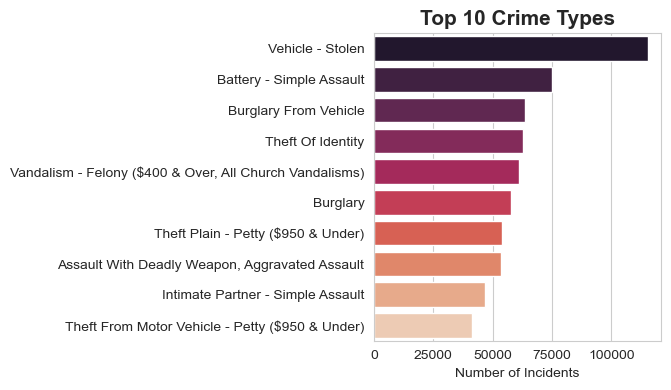

In [18]:
top_crimes = crime['Crm Cd Desc'].value_counts().head(10)

plt.figure(figsize=(7, 4))
sns.barplot(x=top_crimes.values, y=top_crimes.index, hue=top_crimes.index, palette='rocket', legend=False)
plt.title('Top 10 Crime Types', fontsize=15, fontweight='bold')
plt.xlabel('Number of Incidents')
plt.ylabel('')
plt.tight_layout()
plt.show()

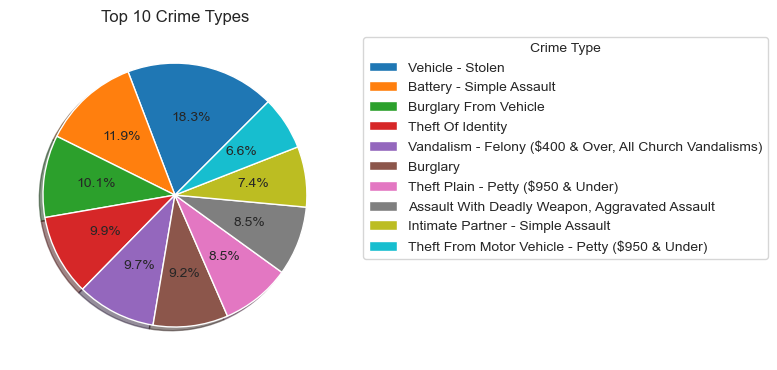

In [19]:
#Pie Chart {Percent-wise distribution}
plt.figure(figsize=(8,8))

plt.pie(
    top_crimes.values,
    autopct='%1.1f%%',
    counterclock=True,
    startangle=45,
    shadow=True
)

plt.title('Top 10 Crime Types')
plt.legend(
    top_crimes.index,
    title='Crime Type',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

#### **Inference**     
Vehicle theft is the most common crime.     
Burglary and assault are also significant.    

## **4.2.Area-wise Crime Analysis**
##### Business Question

### **Which areas report the highest number of crimes?**

What are we analyzing?  
Crime frequency in each police division.   
Distribution of crimes across regions.  

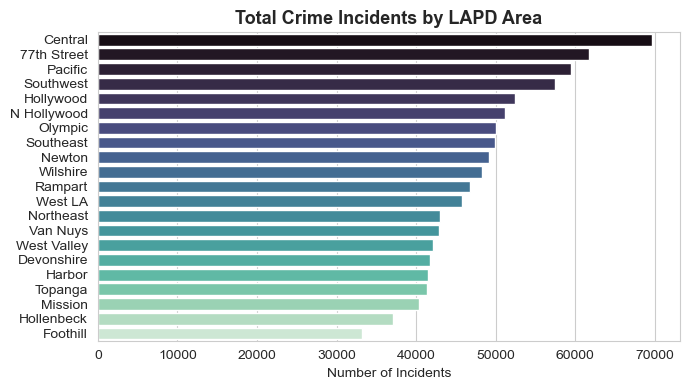

In [20]:
#BarPlot
area_counts = crime['AREA NAME'].value_counts()

plt.figure(figsize=(7, 4))
sns.barplot(x=area_counts.values, y=area_counts.index, hue=area_counts.index, palette='mako', legend=False)
plt.title('Total Crime Incidents by LAPD Area', fontsize=13, fontweight='bold')
plt.xlabel('Number of Incidents')
plt.ylabel('')
plt.tight_layout()
plt.show()

### **Inference:**

Central (70K), 77th Street (61K), and Pacific (60K) report the highest incident volumes,   
while the gap between the highest- and lowest-crime areas suggests that crime is geographically concentrated  
rather than evenly distributed across LAPD patrol areas.  



## **4.3 Case Status Breakdown**
##### Business Question
### **What is the distribution of crime cases across different case statuses?**

What are we analyzing?  
The number of crime cases in each status category (e.g., Investigation continue, adult arrest,etc).  
The proportion of resolved versus unresolved cases.     

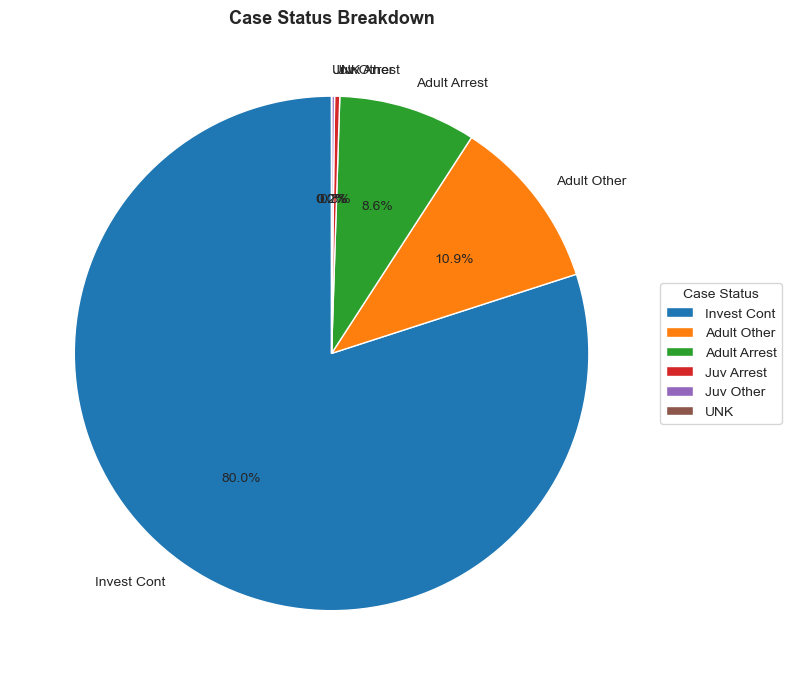

In [54]:
status_counts = crime['Status Desc'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('tab10'), startangle=90)
# Legend on the right side
plt.legend(
    status_counts.index,
    title="Case Status",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)
plt.title('Case Status Breakdown', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Inference:**

80% of cases remain 'Invest Cont' (investigation continuing) —   
meaning the large majority of reported crimes in this dataset have no resolved outcome yet.     
Only ~8.6% resulted in an adult arrest.       

## **4.4 Crime Severity (Part 1 vs Part 2 Offenses)** 

##### Business Question
### **What is the distribution of serious crimes (Part 1) versus less severe crimes (Part 2)?**

What are we analyzing?     
The proportion of Part 1 offenses (serious crimes such as homicide, robbery, burglary, and aggravated assault)   
compared to Part 2 offenses (less severe crimes such as vandalism, fraud, and simple assault).  
The overall severity level of crimes occurring in the region. .  

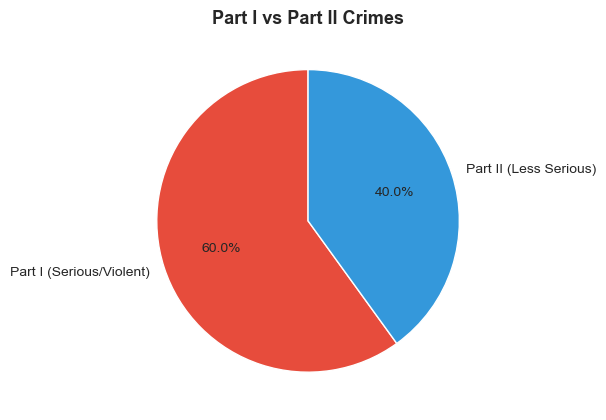

In [22]:
part_counts = crime['Part 1-2'].value_counts()
part_labels = {1: 'Part I (Serious/Violent)', 2: 'Part II (Less Serious)'}

plt.figure(figsize=(6,6))
plt.pie(part_counts.values, labels=[part_labels[i] for i in part_counts.index],
        autopct='%1.1f%%', colors=['#e74c3c', '#3498db'], startangle=90)
plt.title('Part I vs Part II Crimes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Inference**

60% of all recorded incidents are Part I (serious/violent) crimes versus 40% Part II —  
a higher share of serious crime than many cities report. 

# 5. Time Series Analysis

## **5.1 Crime Trend Analysis**
##### Business Question
### **Has crime increased or decreased over the years?**  

What are we analyzing?  
Long-term trend in crime occurrence.  
Growth or decline in crime rates over time.  

In [23]:
# Step 1: Count crimes by year
crime_by_year = crime['Year OCC'].value_counts().sort_index()
crime_by_year

Year OCC
2020    199847
2021    209875
2022    235258
2023    232350
2024    127574
2025       294
Name: count, dtype: int64

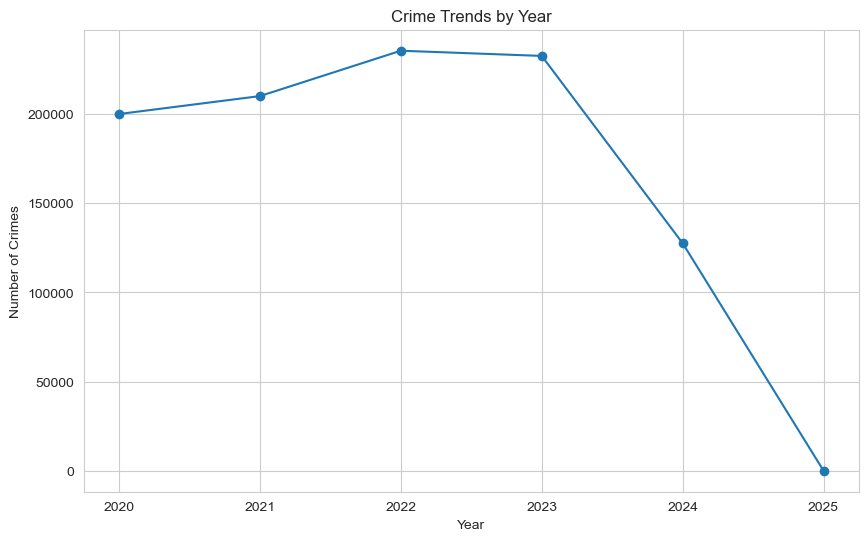

In [24]:
# Step 2: Create Line Chart
# plt.figure(figsize=(5,4))
crime_by_year.plot(
    kind='line',
    marker='o'
)
plt.title('Crime Trends by Year')
plt.xlabel('Year')
plt.ylabel('Number of Crimes')
plt.show()


**Inference:**  
Crimes increased from 2020 to 2022.  
Slight decline observed after 2022.  
A sudden spike may indicate social or economic factors.

## **5.2 Monthly Seasonality Analysis**
##### Business Question
### **Which months experience the highest and lowest crime occurrences across all years combined?**

What are we analyzing?  
Crime distribution across different months of the year.  
Identification of seasonal patterns and recurring trends in crime occurrence.  

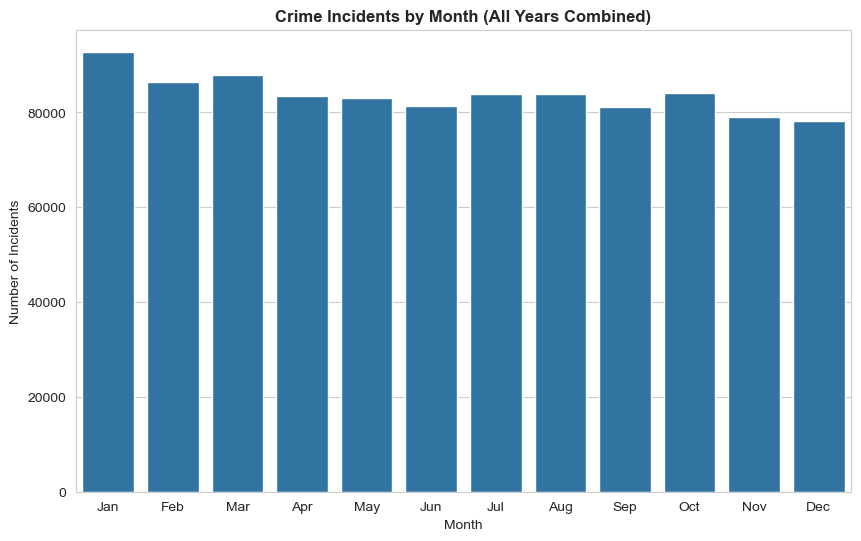

In [25]:
monthly_crime = crime['Month OCC'].value_counts().sort_index()

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

sns.barplot(x=month_names, y=monthly_crime.values)
plt.title('Crime Incidents by Month (All Years Combined)',fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Incidents')
plt.show()

**Inference**  
January has the highest crime incidents  

## **5.3 Crime by Hour of Day Analysis**

##### Business Question
### **At what hours of the day are crimes most frequently reported or committed?**

What are we analyzing?  
Crime distribution across different hours of the day.  
Identification of peak crime periods and low-activity hours.  

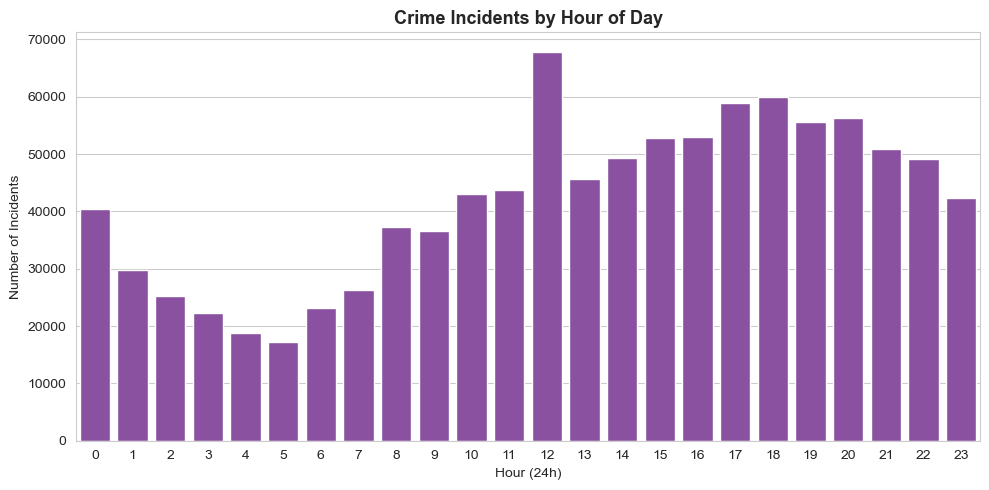

In [26]:
hourly = crime['Hour OCC'].value_counts().sort_index()

plt.figure(figsize=(10,5))
sns.barplot(x=hourly.index, y=hourly.values, color='#8e44ad')
plt.title('Crime Incidents by Hour of Day', fontsize=13, fontweight='bold')
plt.xlabel('Hour (24h)')
plt.ylabel('Number of Incidents')
plt.tight_layout()
plt.show()

**Inference**   
Crime incidents are highest at 12 PM (around 67K cases),  
with another peak during 5–6 PM (around 58K–60K cases).    
The lowest crime levels occur between 3–5 AM (around 17K–22K cases).   
Overall, the busiest hour records nearly 4 times more incidents than the quietest hours.  

## **5.4 Day-of-week x Hour Heatmap**

##### Business Question
### **At what hours and on which days do crimes occur most frequently?**  

What are we analyzing?  
Crime distribution across different days of the week and hours of the day.  
Identification of peak crime periods and low-activity periods.  
Patterns in criminal activity based on time and weekday combinations. 

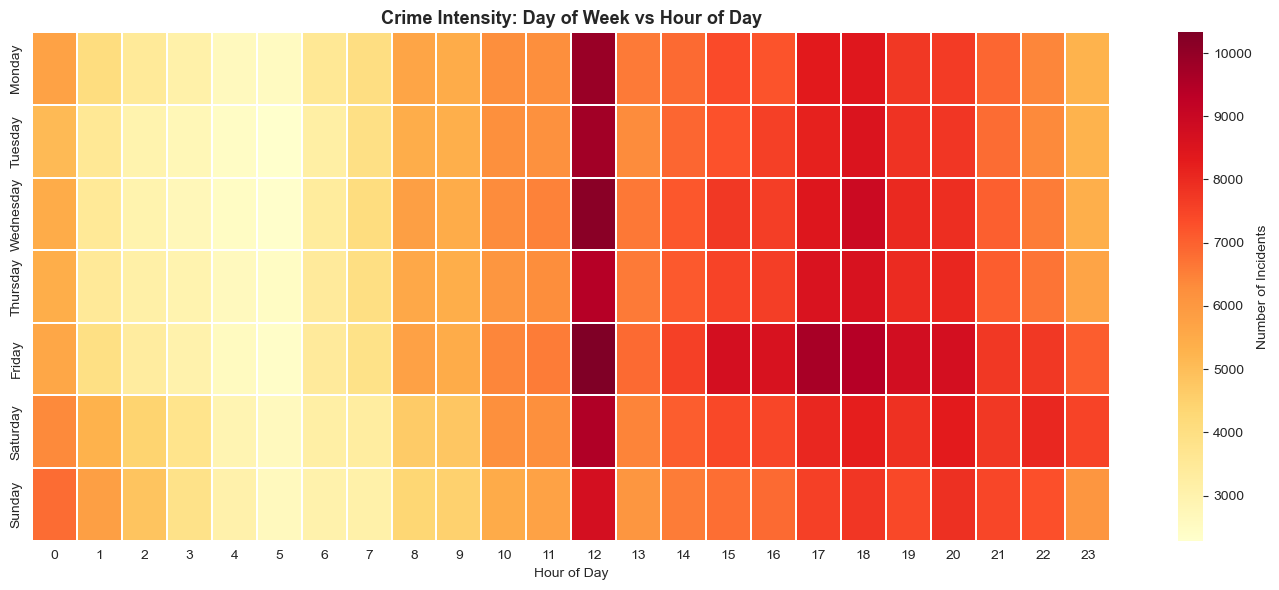

In [27]:
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heat_data = crime.groupby(['Weekday OCC', 'Hour OCC']).size().unstack(fill_value=0)
heat_data = heat_data.reindex(weekday_order)

plt.figure(figsize=(14,6))
sns.heatmap(heat_data, cmap='YlOrRd', linewidths=0.3, cbar_kws={'label': 'Number of Incidents'})
plt.title('Crime Intensity: Day of Week vs Hour of Day', fontsize=13, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Inference**   
Crime incidents are lowest during early morning hours (2 AM – 6 AM).  
A significant crime peak occurs around 12 PM (Noon) across all days.  
Friday evenings show the highest crime intensity.  
The heatmap highlights key time periods for targeted police patrols and resource allocation

# 6. Geographic Analysis 

## **6.1 Crime hotspot map (scatter of incident locations)**

##### Business Question
### **Which geographic locations experience the highest concentration of crime incidents?**

What are we analyzing?  
Spatial distribution of crime incidents across the city.  
Identification of crime hotspots and high-risk areas  


NOTE : We use only records with valid coordinates (`Location Valid == True`), and sample for plotting performance since we have 1M+ points.  

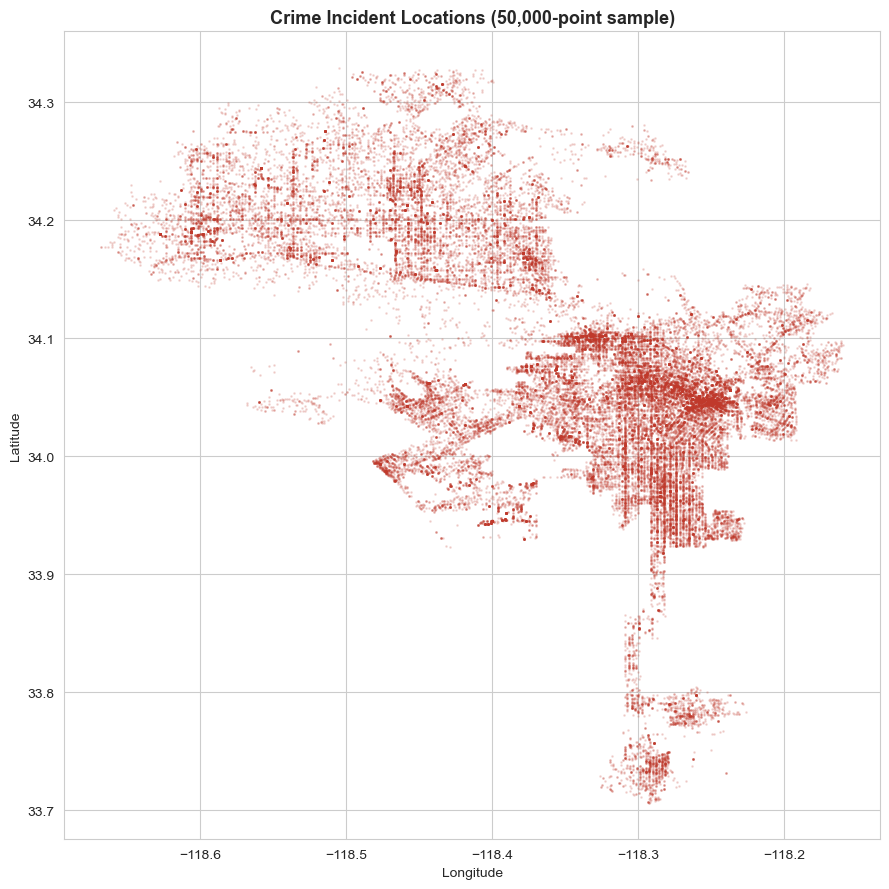

In [28]:
geo_df = crime[crime['Location Valid']].sample(n=50000, random_state=42)

plt.figure(figsize=(9,9))
plt.scatter(geo_df['LON'], geo_df['LAT'], s=1, alpha=0.15, color='#c0392b')
plt.title('Crime Incident Locations (50,000-point sample)', fontsize=13, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

**Inference:**

Even with a sample of 50,000 points, crime locations show clear clusters, especially around downtown and high-traffic commercial areas. This indicates that crime is concentrated in specific regions rather than being evenly distributed across the city.

## **6.2 Density hexbin map (better for spotting hotspots)**
##### Business Question
### **Which locations show the highest density of crime incidents and emerge as major crime hotspots?**

What are we analyzing?
Concentration and density of crime incidents across geographic regions.
Identification of high-intensity crime clusters that may not be visible in a scatter plot.

**HEXBIN MAP:**  
A Hexbin Map (Hexagonal Bin Map) is a visualization used to show the density of points on a map by grouping nearby locations into hexagon-shaped bins instead of plotting every individual point

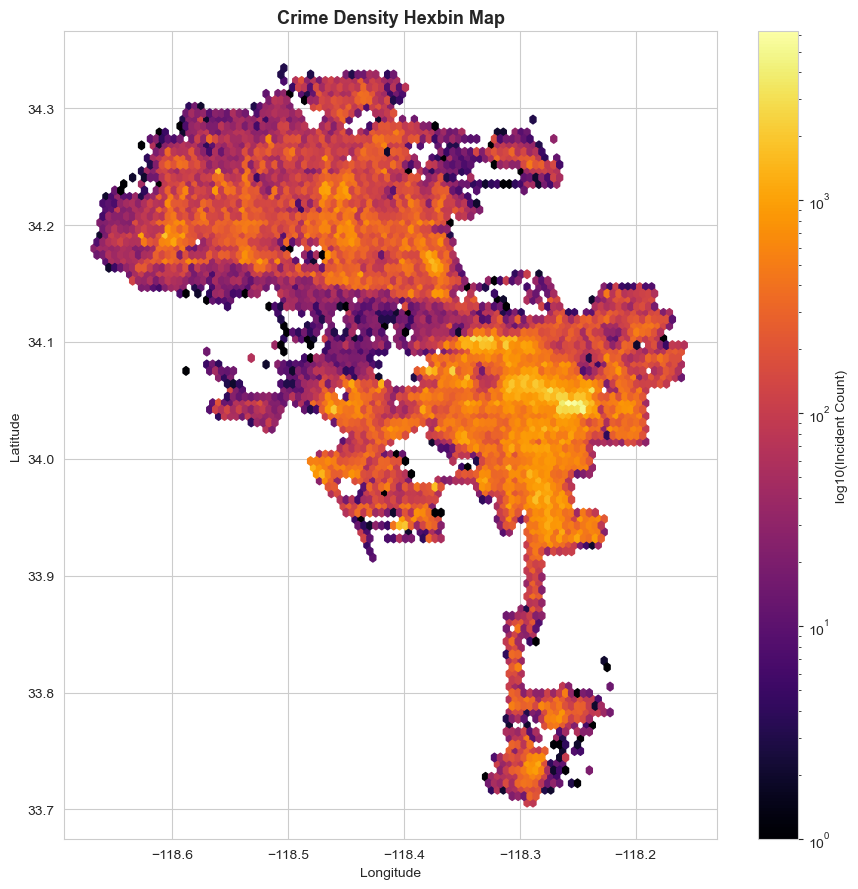

In [29]:
valid_geo = crime[crime['Location Valid']]

plt.figure(figsize=(9,9))
hb = plt.hexbin(valid_geo['LON'], valid_geo['LAT'], gridsize=100, cmap='inferno', mincnt=1, bins='log')
plt.colorbar(hb, label='log10(Incident Count)')
plt.title('Crime Density Hexbin Map', fontsize=13, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

**Inference**   
The hexbin map shows clear crime hotspots around Downtown LA and a few other areas. These hotspots match the high-crime areas identified earlier, such as Central and 77th Street, confirming the same crime pattern from a different perspective.

## **6.3 Top specific locations by incident count**
##### Business Question
### **Which specific locations experience the highest number of crime incidents?**

What are we analyzing?   
Crime frequency at individual locations or addresses.  
Identification of repeat crime locations and micro-level hotspots.  

In [30]:
top_locations = crime['LOCATION'].value_counts().head(15)
top_locations

LOCATION
800 N  ALAMEDA                      ST      2598
700 S  FIGUEROA                     ST      1711
100    THE GROVE                    DR      1688
10200    SANTA MONICA                 BL    1657
6TH                          ST             1585
11800    SANTA MONICA                 BL    1526
7TH                          ST             1502
9300    TAMPA                        AV     1452
7TH                                         1447
6TH                                         1372
600 S  ALVARADO                     ST      1363
5300    LANKERSHIM                   BL     1255
6600    TOPANGA CANYON               BL     1222
FIGUEROA                     ST             1217
HOLLYWOOD                                   1212
Name: count, dtype: int64

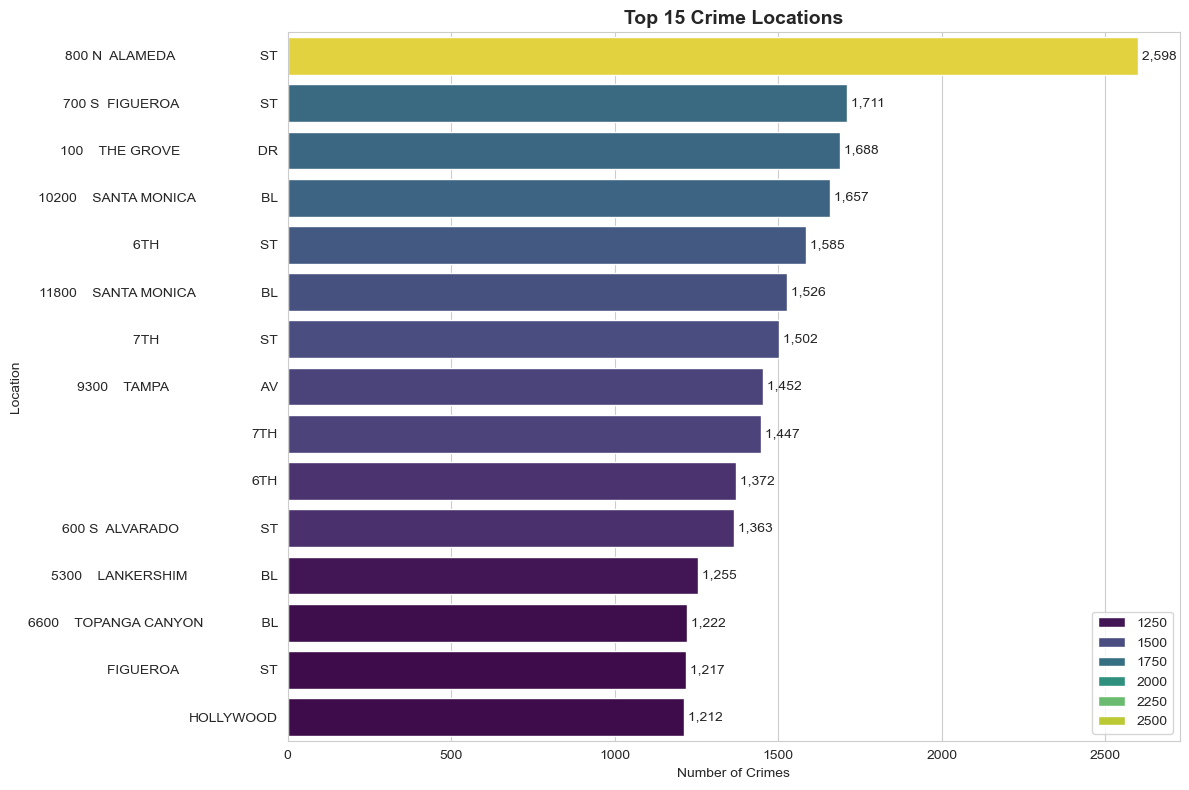

In [46]:
top_locations = crime['LOCATION'].value_counts().head(15)

plt.figure(figsize=(12, 8))

sns.barplot(
    x=top_locations.values,
    y=top_locations.index,
    palette='viridis',
    hue=top_locations.values,
)

plt.title('Top 15 Crime Locations', fontsize=14, fontweight='bold')
plt.xlabel('Number of Crimes')
plt.ylabel('Location')

# Add count labels on bars
for i, value in enumerate(top_locations.values):
    plt.text(value, i, f' {value:,}', va='center')

plt.tight_layout()
plt.show()

**Inference**

800 N Alameda St recorded the highest number of incidents (~2,598 cases).  
This location is in the Downtown/Arts District area.  

# 7. Victim Demographics

## **7.1 Age Distribution Analysis (Valid Ages Only)**

##### Business Question
### **What is the distribution of crime victims across different ages?**

What are we analyzing?  
Distribution of victims across valid age values only.  
Identification of the most affected age groups.  

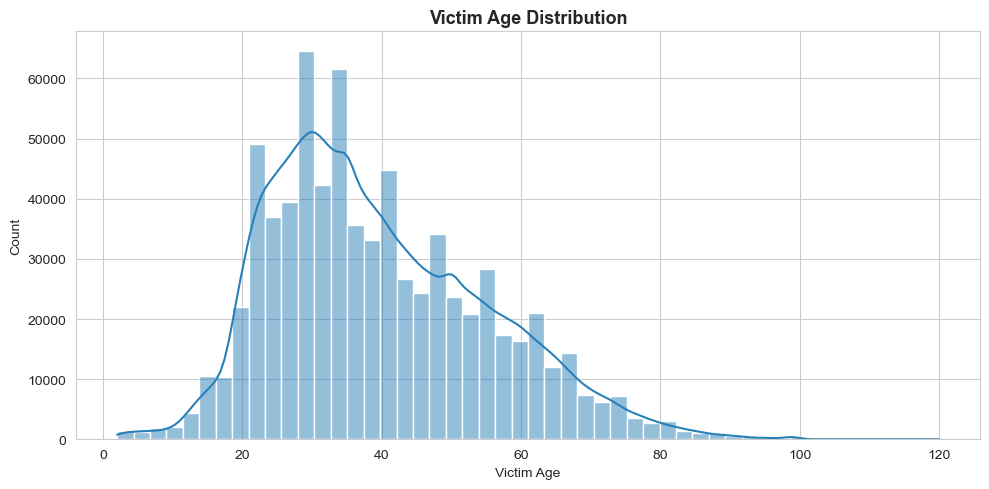

count    735685.000000
mean         39.504682
std          15.572124
min           2.000000
25%          28.000000
50%          37.000000
75%          50.000000
max         120.000000
Name: Vict Age, dtype: float64


In [32]:
valid_age = crime[crime['Vict Age Valid']]

plt.figure(figsize=(10,5))
sns.histplot(valid_age['Vict Age'], bins=50, kde=True, color='#2980b9')
plt.title('Victim Age Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Victim Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(valid_age['Vict Age'].describe())

**Inference**

The median victim age is 37 years (average age is ~39.5 years).  
Most victims are between 28 and 50 years old.  
The number of victims decreases for older age groups.  
Very few victims are under 18 years old.  
This suggests that the dataset is mainly dominated by adult-related crimes.   

## **7.2 Victim Sex Distribution**

##### Business Question
### **How are crime victims distributed across different sexes?**

What are we analyzing?  
Distribution of crime victims by sex.  
Identification of demographic patterns among victims.  

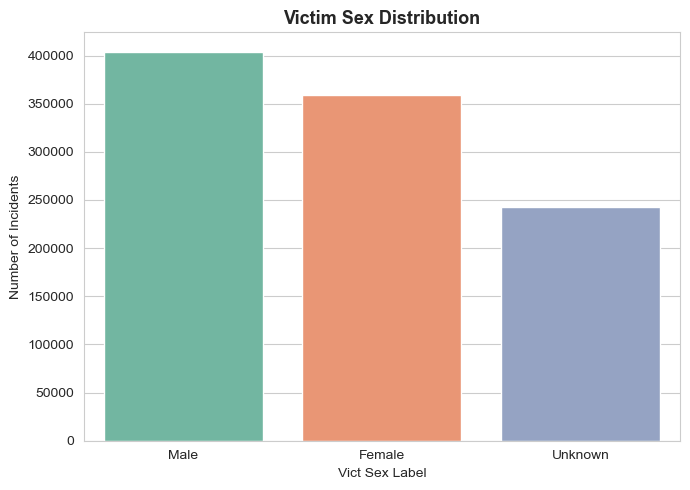

In [33]:
sex_counts = crime['Vict Sex Label'].value_counts()

plt.figure(figsize=(7,5))
sns.barplot(x=sex_counts.index, y=sex_counts.values, hue=sex_counts.index, palette='Set2', legend=False)
plt.title('Victim Sex Distribution', fontsize=13, fontweight='bold')
plt.ylabel('Number of Incidents')
plt.tight_layout()
plt.show()

**Inference**   

Male victims (40.2%) slightly outnumber female victims (35.7%).  
Around 24.1% of records have unknown or not applicable victim gender.  
The proportion of male and female victims is relatively similar.  
This suggests that victim gender alone may not strongly influence crime type.   

## **7.3 Victim Descent Distribution (Top 10)**

##### Business Question
### **Which victim descent groups are most frequently affected by crime?**

What are we analyzing?  
Distribution of crime victims across the top 10 descent groups.  
Identification of demographic patterns in victimization.   

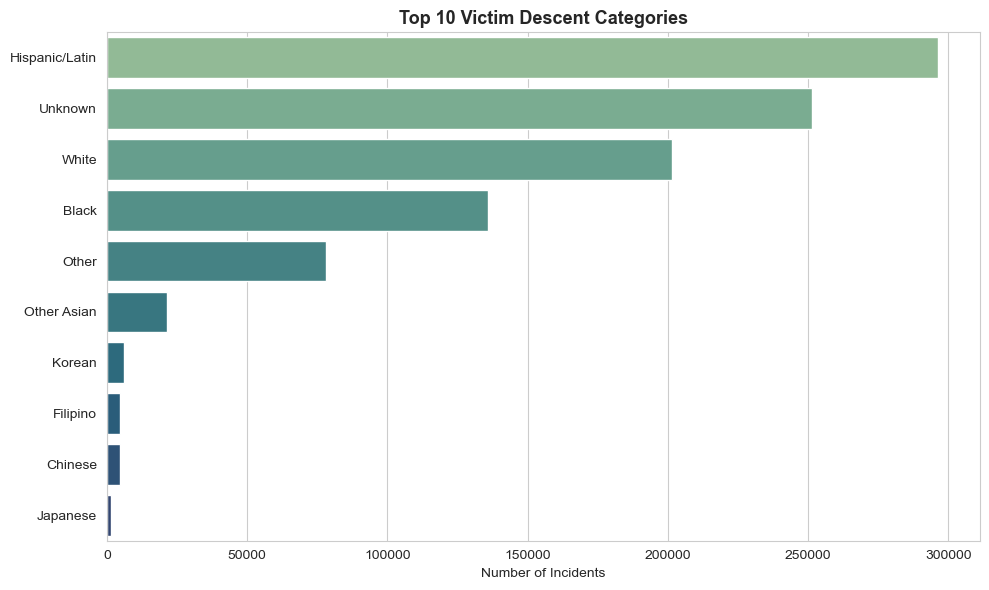

In [34]:
descent_counts = crime['Vict Descent Label'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=descent_counts.values, y=descent_counts.index, hue=descent_counts.index, palette='crest', legend=False)
plt.title('Top 10 Victim Descent Categories', fontsize=13, fontweight='bold')
plt.xlabel('Number of Incidents')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Inference**

Hispanic/Latino victims (~29.5%) make up the largest group.   


## **7.4 Crime Type by Victim Sex (Top 8 Crimes)**
#### Business Question
### **Do the most common crime types differ between male and female victims?**

What are we analyzing?  
Distribution of the top 8 crime types across victim sex categories.  
Relationship between victim sex and the type of crime experienced.   

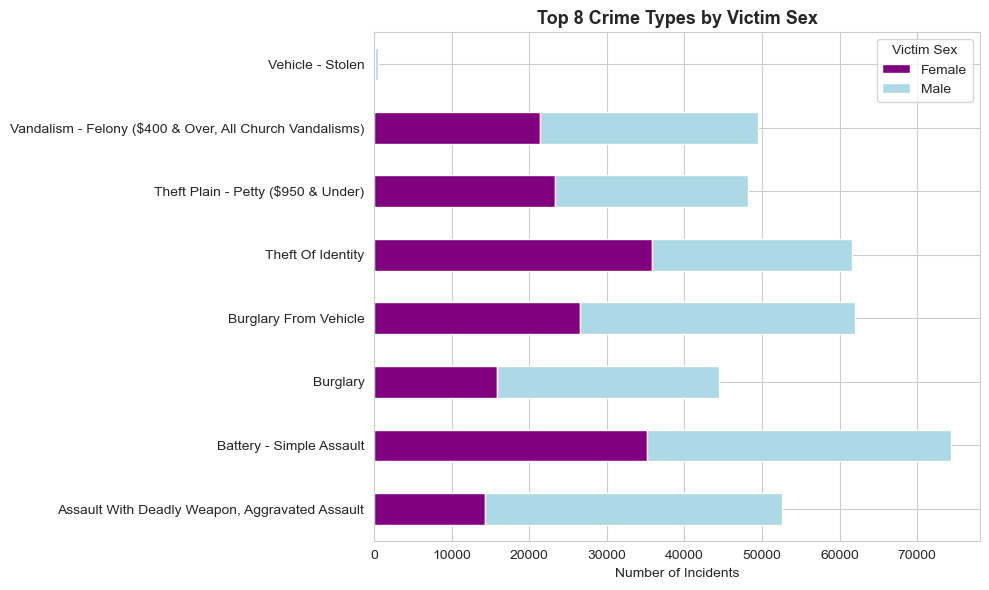

In [35]:
top8 = crime['Crm Cd Desc'].value_counts().head(8).index
cross = crime[crime['Crm Cd Desc'].isin(top8) & (crime['Vict Sex Label'] != 'Unknown')]
cross_tab = pd.crosstab(cross['Crm Cd Desc'], cross['Vict Sex Label'])

cross_tab.plot(kind='barh', stacked=True, figsize=(10,6), color=['purple', 'lightblue'])
plt.title('Top 8 Crime Types by Victim Sex', fontsize=13, fontweight='bold')
plt.xlabel('Number of Incidents')
plt.ylabel('')
plt.legend(title='Victim Sex')
plt.tight_layout()
plt.show()

**Inference**

Most major crime types have a higher number of male victims than female victims.  
Battery - Simple Assault has the highest number of incidents for both sexes.  
Identity Theft shows a relatively higher share of female victims compared to other crimes. 
This indicates that victim sex distribution varies across crime types.  



# 8. Crime Type & Weapon Analysis

## **8.1 Most Common Weapons Analysis (When a Weapon is used)**

##### Business Question
### **Which weapons are most frequently used in crimes involving a weapon?**

What are we analyzing?  
Distribution of weapon types used in reported crimes.  
Identification of the most commonly used weapons.   

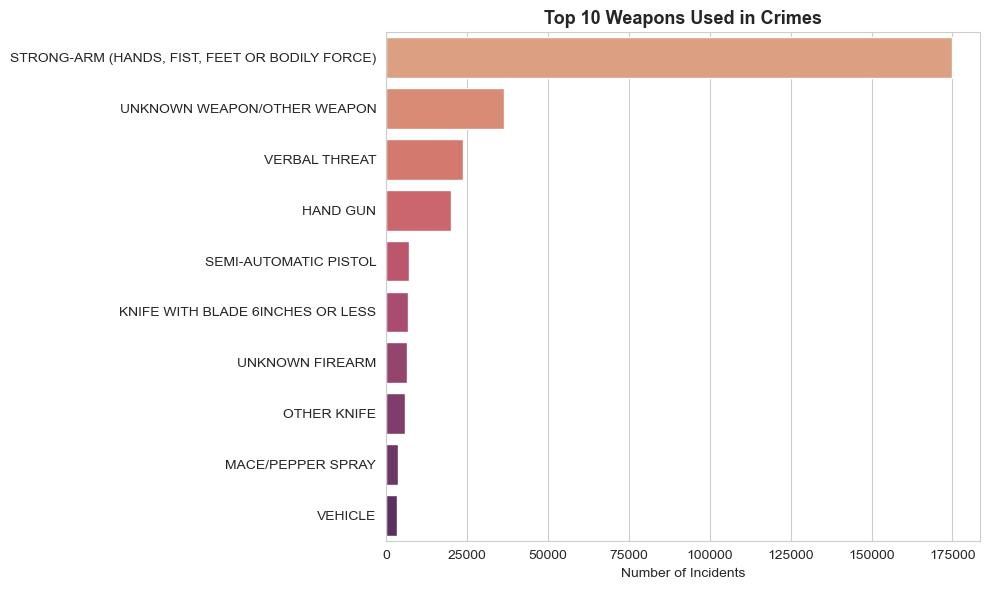

In [36]:
weapon_used = crime[crime['Weapon Desc Clean'] != 'No Weapon Involved']['Weapon Desc Clean'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=weapon_used.values, y=weapon_used.index, hue=weapon_used.index, palette='flare', legend=False)
plt.title('Top 10 Weapons Used in Crimes', fontsize=13, fontweight='bold')
plt.xlabel('Number of Incidents')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Inference**

Strong-Arm (hands, fists, feet, or bodily force) is the most commonly recorded weapon   (175K incidents).   
This suggests that physical assaults are more common than gun-related crimes in the   dataset.  

## **8.2 Weapon Involvement Rate by Crime Type (Top 10 Crimes)**

##### Business Question
### **Which major crime types are most likely to involve a weapon?**

What are we analyzing?  
Percentage of incidents involving a weapon within the top 10 crime categories.  
Comparison of weapon involvement rates across different crime types.  

In [37]:
top10_crimes = crime['Crm Cd Desc'].value_counts().head(10).index

temp = crime[crime['Crm Cd Desc'].isin(top10_crimes)].copy()
temp['Weapon Used'] = temp['Weapon Desc Clean'] != 'No Weapon Involved'

weapon_rate = temp.groupby('Crm Cd Desc')['Weapon Used'].mean() * 100
weapon_rate = weapon_rate.sort_values(ascending=False)

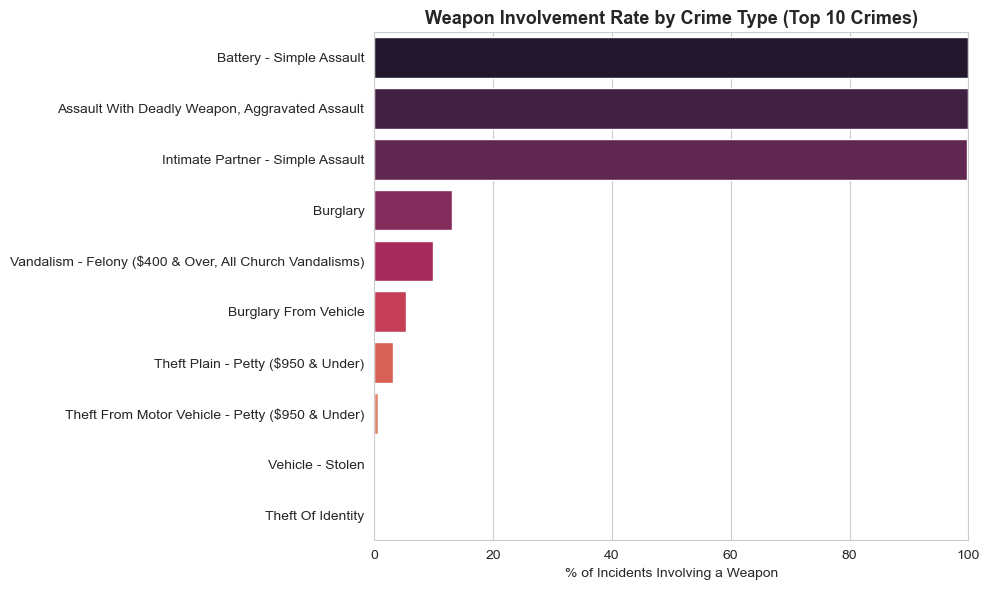

In [38]:
# Top 10 most common crime types
top10_crimes = crime['Crm Cd Desc'].value_counts().head(10).index

# Filter only those crimes
temp = crime[crime['Crm Cd Desc'].isin(top10_crimes)].copy()

# Create weapon involvement flag
temp['Weapon Used'] = temp['Weapon Desc Clean'] != 'No Weapon Involved'

# Calculate weapon involvement percentage
weapon_rate = (
    temp.groupby('Crm Cd Desc')['Weapon Used']
    .mean() * 100
).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(
    x=weapon_rate.values,
    y=weapon_rate.index,
    hue=weapon_rate.index,
    palette='rocket',
    legend=False
)


plt.title('Weapon Involvement Rate by Crime Type (Top 10 Crimes)',
          fontsize=13, fontweight='bold')
plt.xlabel('% of Incidents Involving a Weapon')
plt.ylabel('')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

**Inference**

Assault-related crimes almost always involve a weapon.  
In contrast, property crimes such as Vehicle Theft and Identity Theft rarely involve weapons.   
This shows a strong relationship between crime type and weapon involvement.  

## **8.3 Premise Types Most Associated with Crime**

##### Business Question
### **Which types of premises experience the highest number of crime incidents?**

What are we analyzing?   
Distribution of crime incidents across different premise types (e.g., streets, residences, parking lots, businesses).   

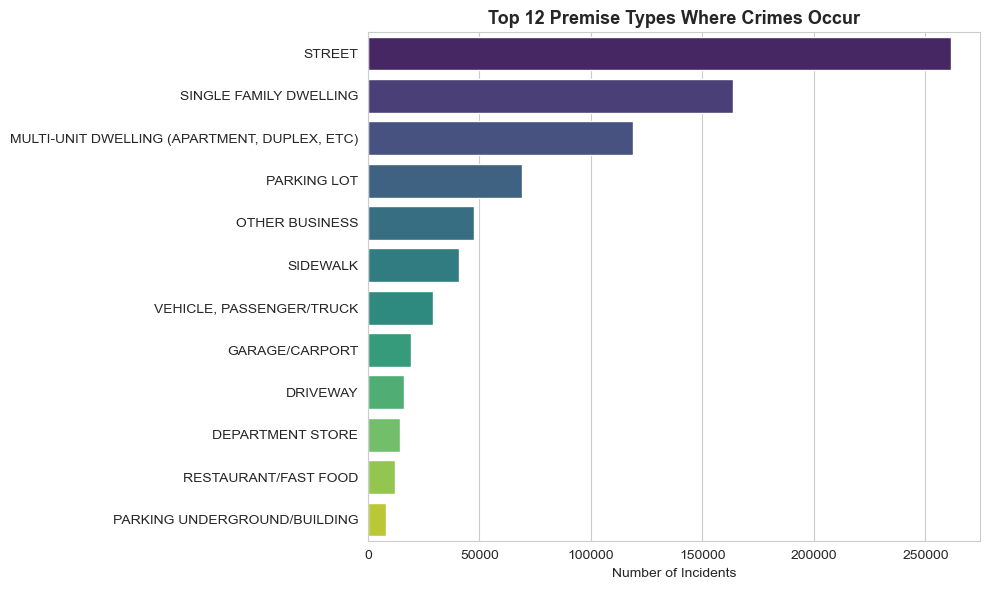

In [39]:
premise_counts = crime['Premis Desc'].value_counts().head(12)

plt.figure(figsize=(10,6))
sns.barplot(x=premise_counts.values, y=premise_counts.index, hue=premise_counts.index, palette='viridis', legend=False)
plt.title('Top 12 Premise Types Where Crimes Occur', fontsize=13, fontweight='bold')
plt.xlabel('Number of Incidents')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Inference**   
Street is the most common crime location (260K incidents).  
It is followed by Single Family Dwellings (160K) and Multi-Unit Dwellings (110K).  
Most crimes occur in public spaces and residential areas rather than commercial locations.  

# 9. Summary

### This project analyzed Los Angeles crime data (2020–2025) to understand crime patterns across time, location, victims, and crime types.

### **Key Findings:**   
* Battery, vehicle theft, and burglary were the most common crimes.  
* Crime was concentrated in a few areas, creating clear hotspots.  
* Most incidents occurred during the afternoon and evening.  
* Streets and residential areas were the most common crime locations.  
* Young and middle-aged adults were the most affected victim groups.  
* Many cases remained under investigation, while fewer resulted in arrests.  
* Weapons were not used in most crimes, but when involved, handguns and strong-arm methods were common.

### **Prescriptive Analysis (What actions should be taken?)**

Based on the EDA findings, the following recommendations can help reduce crime and improve public safety:

* Increase police patrols in crime hotspot areas and during peak crime hours (afternoon and evening).
* Deploy additional resources in streets and residential neighborhoods, where most incidents occur.
* Launch targeted awareness and prevention programs for the most affected victim groups.
* Use predictive models to identify high-risk locations and time periods before crimes occur.
* Prioritize investigation efforts for crime categories with low case resolution rates.
* Strengthen surveillance and security measures in areas with high rates of vehicle theft and burglary.
* Continuously monitor crime trends and update policing strategies based on new data.

### **Conclusion**   

By combining EDA insights with predictive models and proactive actions, law enforcement agencies can move from reactive policing to data-driven crime prevention.

# 10. Dashboard

## LA Crime Data — KPI Dashboard 

Interactive EDA dashboard built with **pandas** + **Plotly** + **ipywidgets**.
Pick a year from the dropdown below and every KPI and chart updates in place.

> make sure the packages below are installed:
> ```
> pip install pandas plotly ipywidgets
> ```
> jupyter nbextension enable --py widgetsnbextension
> ```

In [40]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

pd.options.mode.chained_assignment = None

## 1. Load data

In [41]:

COLS = [
    'AREA NAME', 'Crm Cd Desc', 'Vict Age', 'Vict Sex Label', 'Vict Descent Label',
    'Weapon Desc Clean', 'Status Desc', 'Year OCC', 'Month OCC', 'Weekday OCC',
    'Hour OCC', 'Age_Group'
]

df = pd.read_csv(r"C:\Users\abc\OneDrive\Documents\ShrushtiPython\LA_Crime_Data_Cleaned.csv", usecols=COLS)
print(f"Loaded {len(df):,} records spanning {df['Year OCC'].min()}–{df['Year OCC'].max()}")
df.head()

Loaded 1,005,198 records spanning 2020–2025


,AREA NAME,Crm Cd Desc,Vict Age,Status Desc,Hour OCC,Year OCC,Month OCC,Weekday OCC,Vict Sex Label,Vict Descent Label,Weapon Desc Clean,Age_Group
0,Wilshire,Vehicle - Stolen,0,Adult Arrest,21,2020,3,Sunday,Male,Other,No Weapon Involved,NaN
1,Central,Burglary From Vehicle,47,Invest Cont,18,2020,2,Saturday,Male,Other,No Weapon Involved,46-60
2,Southwest,Bike - Stolen,19,Invest Cont,17,2020,11,Wednesday,Unknown,Unknown,No Weapon Involved,19-30
3,Van Nuys,Shoplifting-Grand Theft ($950.01 & Over),19,Invest Cont,20,2020,3,Tuesday,Male,Other,No Weapon Involved,19-30
4,Hollenbeck,Vehicle - Stolen,0,Invest Cont,6,2020,9,Wednesday,Unknown,Unknown,No Weapon Involved,NaN


## 2. Build per-year KPI summaries

This mirrors the logic from the HTML dashboard, computed natively in pandas.

In [42]:
WEEKDAY_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
MONTH_NAMES   = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
AGE_ORDER     = ['0-18','19-30','31-45','46-60','60+']

def build_summary(sub: pd.DataFrame) -> dict:
    n = len(sub)
    d = {'total': n}

    status_counts = sub['Status Desc'].value_counts()
    arrest_mask = [s for s in status_counts.index if 'Arrest' in s]
    arrests = status_counts[arrest_mask].sum() if arrest_mask else 0
    d['arrest_rate'] = round(100 * arrests / n, 2) if n else 0.0
    d['status'] = status_counts

    valid_age = sub.loc[sub['Vict Age'] > 0, 'Vict Age']
    d['avg_age'] = round(valid_age.mean(), 1) if len(valid_age) else 0.0

    d['crimes'] = sub['Crm Cd Desc'].value_counts().head(12)
    d['top_crime'] = d['crimes'].index[0] if len(d['crimes']) else '—'

    d['area'] = sub['AREA NAME'].value_counts()
    d['top_area'] = d['area'].index[0] if len(d['area']) else '—'

    d['month'] = sub['Month OCC'].value_counts().sort_index()
    d['weekday'] = sub['Weekday OCC'].value_counts().reindex(WEEKDAY_ORDER).fillna(0)
    d['hour'] = sub['Hour OCC'].value_counts().sort_index()

    d['sex'] = sub['Vict Sex Label'].value_counts()
    d['descent'] = sub['Vict Descent Label'].value_counts().head(6)
    d['age_group'] = sub['Age_Group'].value_counts().reindex(AGE_ORDER).dropna()

    d['weapon'] = sub['Weapon Desc Clean'].value_counts()
    no_weapon = d['weapon'].get('No Weapon Involved', 0)
    d['pct_no_weapon'] = round(100 * no_weapon / n, 2) if n else 0.0

    return d

YEARS = sorted(df['Year OCC'].unique().tolist())
BY_YEAR = {str(y): build_summary(df[df['Year OCC'] == y]) for y in YEARS}
BY_YEAR['All'] = build_summary(df)

print("Years available:", YEARS)

Years available: [2020, 2021, 2022, 2023, 2024, 2025]


## 3. KPI card renderer

In [43]:
def kpi_html(year: str, d: dict) -> str:
    label = f"{YEARS[0]}–{YEARS[-1]}" if year == 'All' else year
    arrests = d['status'].get('Adult Arrest', 0) + d['status'].get('Juv Arrest', 0)
    top_crime_share = (100 * d['crimes'].get(d['top_crime'], 0) / d['total']) if d['total'] else 0

    cards = [
        ("Total Reported Incidents" if year == 'All' else f"Incidents in {year}", f"{d['total']:,}", f"{label} \u00b7 {d['total']:,} records"),
        ("Arrest Rate", f"{d['arrest_rate']}%", f"{arrests:,} arrests logged"),
        ("Most Reported Crime", d['top_crime'], f"{top_crime_share:.1f}% of incidents"),
        ("Highest-Volume Division", d['top_area'], f"{d['area'].get(d['top_area'], 0):,} incidents"),
        ("Avg. Victim Age", f"{d['avg_age']} yrs", f"{d['pct_no_weapon']}% incidents unarmed"),
    ]

    style = """
    <style>
      .kpi-wrap{display:flex;gap:12px;flex-wrap:wrap;font-family:-apple-system,Segoe UI,Roboto,sans-serif;margin-bottom:8px;}
      .kpi-card{background:#161b21;border:1px solid rgba(255,255,255,0.08);border-radius:12px;
                padding:14px 16px;min-width:170px;flex:1;color:#eef1f4;}
      .kpi-card .l{font-size:10.5px;text-transform:uppercase;letter-spacing:.10em;color:#8b93a1;font-weight:700;}
      .kpi-card .v{font-size:20px;font-weight:800;margin-top:6px;}
      .kpi-card .f{font-size:11.5px;color:#8b93a1;margin-top:4px;}
    </style>
    """
    body = "".join(
        f'<div class="kpi-card"><div class="l">{lab}</div><div class="v">{val}</div><div class="f">{foot}</div></div>'
        for lab, val, foot in cards
    )
    return style + f'<div class="kpi-wrap">{body}</div>'

## 4. Chart builder
    
Builds the full grid of Plotly figures for a given year's summary.

In [44]:
TEMPLATE = "plotly_dark"
COLORS = dict(accent="#ff5a36", accent2="#2fb4c9", accent3="#f2b705", good="#3ecf8e", purple="#9b7bff")

def build_figures(year: str, d: dict):
    figs = []

    # Yearly trend (always full range, current year highlighted)
    totals = [BY_YEAR[str(y)]['total'] for y in YEARS]
    bar_colors = [COLORS['accent'] if (year != 'All' and str(y) == year) else 'rgba(255,90,54,0.35)' for y in YEARS]
    fig = go.Figure(go.Bar(x=[str(y) for y in YEARS], y=totals, marker_color=bar_colors))
    fig.update_layout(template=TEMPLATE, title="Reported Incidents by Year", height=320, margin=dict(t=40,b=20))
    figs.append(fig)

    # Top crimes
    fig = px.bar(d['crimes'].sort_values(), orientation='h', template=TEMPLATE,
                 labels={'value':'incidents','index':''}, title="Top Crime Types")
    fig.update_traces(marker_color=COLORS['accent2'])
    fig.update_layout(height=340, showlegend=False, margin=dict(t=40,b=20))
    figs.append(fig)

    # Hour of day
    fig = px.bar(x=d['hour'].index.astype(str)+":00", y=d['hour'].values, template=TEMPLATE,
                 labels={'x':'hour','y':'incidents'}, title="Incidents by Hour of Day")
    fig.update_traces(marker_color=COLORS['accent3'])
    fig.update_layout(height=300, showlegend=False, margin=dict(t=40,b=20))
    figs.append(fig)

    # Weekday
    fig = px.bar(x=d['weekday'].index, y=d['weekday'].values, template=TEMPLATE,
                 labels={'x':'','y':'incidents'}, title="Incidents by Day of Week")
    fig.update_traces(marker_color=COLORS['good'])
    fig.update_layout(height=300, showlegend=False, margin=dict(t=40,b=20))
    figs.append(fig)

    # Monthly seasonality
    month_x = [MONTH_NAMES[m-1] for m in d['month'].index]
    fig = px.line(x=month_x, y=d['month'].values, template=TEMPLATE, markers=True,
                   labels={'x':'','y':'incidents'}, title="Seasonality by Month")
    fig.update_traces(line_color=COLORS['purple'])
    fig.update_layout(height=300, showlegend=False, margin=dict(t=40,b=20))
    figs.append(fig)

    # Area breakdown
    fig = px.bar(d['area'].sort_values(), orientation='h', template=TEMPLATE,
                 labels={'value':'incidents','index':''}, title="Incidents by Patrol Division")
    fig.update_traces(marker_color=COLORS['accent'])
    fig.update_layout(height=460, showlegend=False, margin=dict(t=40,b=20))
    figs.append(fig)

    # Case status
    fig = px.pie(names=d['status'].index, values=d['status'].values, template=TEMPLATE,
                 title="Case Status Breakdown", hole=0.55)
    fig.update_layout(height=340, margin=dict(t=40,b=20))
    figs.append(fig)

    # Victim sex
    fig = px.pie(names=d['sex'].index, values=d['sex'].values, template=TEMPLATE,
                 title="Victim Sex", hole=0.5)
    fig.update_layout(height=300, margin=dict(t=40,b=20))
    figs.append(fig)

    # Age group
    fig = px.bar(x=d['age_group'].index, y=d['age_group'].values, template=TEMPLATE,
                 labels={'x':'','y':'victims'}, title="Victim Age Group")
    fig.update_traces(marker_color=COLORS['accent3'])
    fig.update_layout(height=300, showlegend=False, margin=dict(t=40,b=20))
    figs.append(fig)

    # Descent
    fig = px.bar(d['descent'].sort_values(), orientation='h', template=TEMPLATE,
                 labels={'value':'victims','index':''}, title="Victim Descent (Top 6)")
    fig.update_traces(marker_color=COLORS['good'])
    fig.update_layout(height=300, showlegend=False, margin=dict(t=40,b=20))
    figs.append(fig)

    # Weapon (excluding "no weapon" for scale)
    weapon_no_none = d['weapon'].drop('No Weapon Involved', errors='ignore').head(10)
    fig = px.bar(weapon_no_none.sort_values(), orientation='h', template=TEMPLATE,
                 labels={'value':'incidents','index':''}, title="Weapon Involvement (Top Categories)")
    fig.update_traces(marker_color=COLORS['purple'])
    fig.update_layout(height=380, showlegend=False, margin=dict(t=40,b=20))
    figs.append(fig)

    # Weapon presence donut
    no_weapon = d['weapon'].get('No Weapon Involved', 0)
    weapon_present = d['total'] - no_weapon
    fig = px.pie(names=['No Weapon Involved','Weapon Involved'], values=[no_weapon, weapon_present],
                 template=TEMPLATE, title="Weapon Presence", hole=0.6,
                 color_discrete_sequence=['#3a4048', COLORS['accent']])
    fig.update_layout(height=340, margin=dict(t=40,b=20))
    figs.append(fig)

    return figs

## 5. Dropdown widget + live render

Run this cell — pick a year from the dropdown and the whole dashboard updates below it.

In [45]:
year_dropdown = widgets.Dropdown(
    options=['All'] + [str(y) for y in YEARS],
    value='All',
    description='Year:',
    style={'description_width': 'initial'}
)
output = widgets.Output()

def render(change=None):
    year = year_dropdown.value
    d = BY_YEAR[year]
    with output:
        clear_output(wait=True)
        display(HTML(kpi_html(year, d)))
        for fig in build_figures(year, d):
            fig.show()

year_dropdown.observe(render, names='value')

display(year_dropdown, output)
render()

Dropdown(description='Year:', options=('All', '2020', '2021', '2022', '2023', '2024', '2025'), style=Descripti…

Output()